# Handwritten Digits - MNIST GAN With Improved Training

Make Your First GAN With PyTorch, 2020

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

import pandas, numpy, random
import matplotlib.pyplot as plt

## Dataset Class

In [3]:
mnist_dataset = datasets.MNIST('./dataset',  train=True, download=True, 
                                transform = transforms.Compose([
                                    transforms.ToTensor(), 
                                    transforms.Normalize(mean=(0.5,), std=(0.5,))
                                ]))                                
# train_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=128, shuffle=True, drop_last=True) 

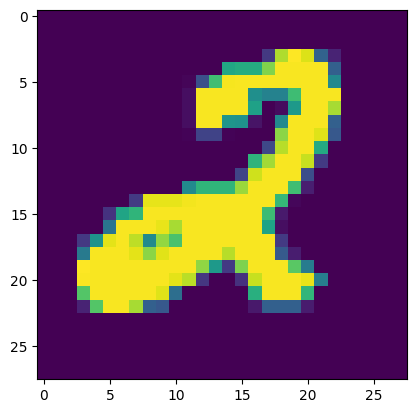

In [42]:
# 查看其中任意一个样本
idx = 385
plt.imshow(mnist_dataset.train_data[idx,:,:].numpy())

In [16]:
mnist_dataset.train_labels[idx]

tensor(9)

In [17]:
# 遍历一遍，什么也不做，就看看有没有问题，避免无故的训练中断
for data, label in mnist_dataset:
    pass

/opt/venv/torch/lib/python3.10/site-packages/torchvision/transforms.py:36: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(pic.tobytes()))


## Data Functions

In [18]:
# functions to generate random data
def generate_random_image(size):
    random_data = torch.rand(size)
    return random_data

def generate_random_seed(size):
    random_data = torch.randn(size)
    return random_data

In [19]:
torch.cuda.is_available()

True

In [20]:
torch.__version__

'2.1.1+cu121'

## Discriminator Network

In [21]:
class Discriminator(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        # define neural network layers
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.LayerNorm(512),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.LayerNorm(256),
            nn.Linear(256, 1),   nn.Sigmoid() )
        
        # create loss function
        self.loss_function = nn.BCELoss()

        # create optimiser, simple stochastic gradient descent
        self.optimiser = torch.optim.Adam(self.parameters(), lr=0.0001)

        # counter and accumulator for progress
        self.counter = 1;
        self.progress = []

        pass
    
    
    def forward(self, inputs):
        # simply run model
        return self.model(inputs)
    
    
    def train(self, inputs, targets):
        # calculate the output of the network
        outputs = self.forward(inputs)
        
        # calculate loss
        loss = self.loss_function(outputs, targets)

        # increase counter and accumulate error every 10
        self.counter += 1
        if (self.counter % 50 == 0):
            self.progress.append(loss.item())
            pass
        if (self.counter % 10000 == 0):
            print("counter = ", self.counter)
            pass

        # zero gradients, perform a backward pass, update weights
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()

        pass
    
    
#    def plot_progress(self):
#        df = pandas.DataFrame(self.progress, columns=['loss'])
#        df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='.', grid=True) #,yticks=(0, 0.25, 0.5, 1.0, 5.0)
#        pass
    
    pass

## Test Discriminator

![sample pic](gan-train-discriminator.png)

In [22]:
%%time
# test discriminator can separate real data from random noise
# 用于估算整体训练时间，这里只取少量数据做时间测试
D = Discriminator()
idx = 1
for img, label in mnist_dataset:
    if idx == 500:    # only do batch_idx times
        break
    idx += 1

    # train with real data, remember that the target tensor should be sized [1,1] 
    D.train(img.reshape(1,784), torch.FloatTensor([[1.0]]))   #  

    # train with fake data, and the target tensor should be sized [1]!
    D.train(generate_random_image(784), torch.FloatTensor([0.0]))   

    pass

CPU times: user 1min 35s, sys: 1.5 s, total: 1min 37s
Wall time: 5.65 s


<Axes: >

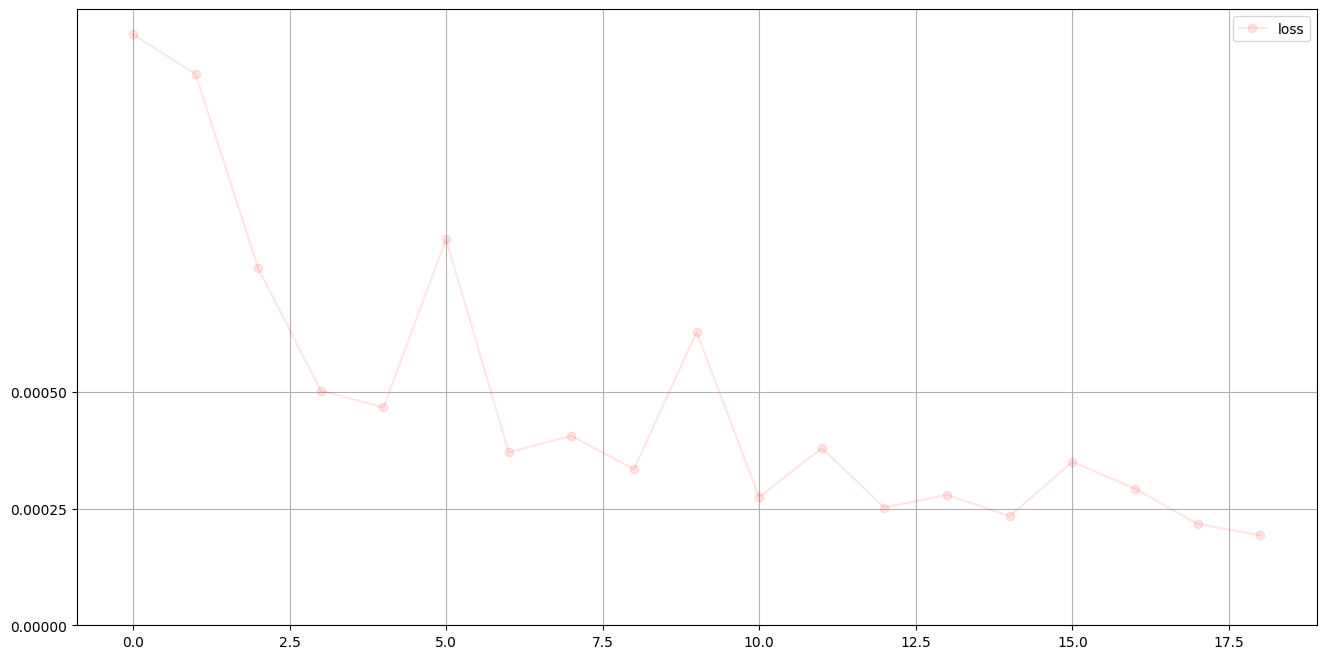

In [23]:
# plot discriminator loss  # 查看误差下降的趋势，可根据误差情况适当调整训练参数
# D.plot_progress()   # 不应集成在class内部
df = pandas.DataFrame(D.progress, columns=['loss'])
df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='o', colormap='prism', grid=True, yticks=(0, 0.00025, 0.0005))

In [24]:
# manually run discriminator to check it can tell real data from fake
# 1. real data test
for i in range(4):
  image_data_tensor = mnist_dataset[random.randint(0,60000)][0]
  print( D.forward( image_data_tensor.reshape(1,784) ).item() )
  pass
# 2. fake data test
for i in range(4):
  print( D.forward( generate_random_image([784]) ).item() )
  pass

0.999790370464325
0.9998133778572083
0.9998354911804199
0.999790608882904
0.00018724831170402467
0.00018796903896145523
0.0001831018744269386
0.0002000952954404056


## Generator Network

In [25]:
class Generator(nn.Module):
    
    def __init__(self):
        # initialise parent pytorch class
        super().__init__()
        
        # define neural network layers
        self.generate = nn.Sequential(
            nn.Linear(50, 128), nn.LeakyReLU(0.2), nn.LayerNorm(128),
            nn.Linear(128, 256), nn.LeakyReLU(0.2), nn.LayerNorm(256),
            nn.Linear(256, 512), nn.LeakyReLU(0.2), nn.LayerNorm(512),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.LayerNorm(1024),
            nn.Linear(1024, 784), nn.Tanh()
        )
        
        # create optimiser, simple stochastic gradient descent
        self.optimiser = torch.optim.Adam(self.parameters(), lr=0.00005)

        # counter and accumulator for progress
        self.counter = 0;
        self.progress = []
        
        pass
    
    
    def forward(self, inputs):        
        # simply run model
        return self.generate(inputs)
    
    
    def train(self, D, inputs, targets):
        # calculate the output of the network
        g_output = self.forward(inputs)
        
        # pass onto Discriminator
        d_output = D.forward(g_output)
        
        # calculate error
        loss = D.loss_function(d_output, targets)

        # increase counter and accumulate error every 10
        self.counter += 1;
        if (self.counter % 10 == 0):
            self.progress.append(loss.item())
            pass

        # zero gradients, perform a backward pass, update weights
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()

        pass
    
    
 #   def plot_progress(self):
 #       df = pandas.DataFrame(self.progress, columns=['loss'])
 #       df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='.', grid=True, yticks=(0, 0.25, 0.5, 1.0, 5.0))
 #       pass
    
    pass

## Test Generator Output

In [26]:
G = Generator()

In [27]:
output = G.forward(torch.randn(50))   # generate_random_seed(50)

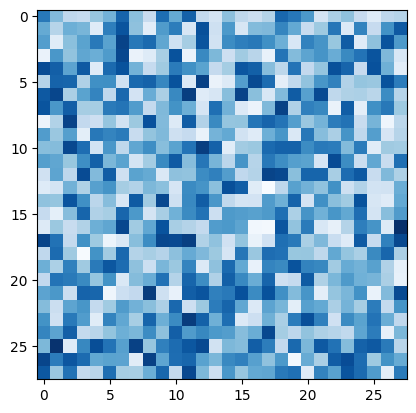

In [28]:
img = output.detach().numpy().reshape(28,28)
plt.imshow(img, interpolation='none', cmap='Blues')

## Train GAN

In [29]:
# Use GPU if available, otherwise stick with cpu
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)

cuda:1


In [ ]:
D = Discriminator().to(device)
G = Generator().to(device)

In [35]:
%%time 

epochs = 50
epoch_size = 50000   # Wall time: 19h 59min 42s CPU times: 19h 46min 6s,

for epoch in range(epochs):
  print ("epoch = ", epoch + 1)

  # train Discriminator and Generator

  idx = 0
  for img, label in mnist_dataset:
    if idx == epoch_size:    # only do batch_idx times
      break
    idx += 1
    
    img = img.to(device)

    # train discriminator on true
    D.train(img.reshape(1,784), torch.FloatTensor([[1.0]]).to(device))
    
    # train discriminator on false
    # use detach() so gradients in G are not calculated
    D.train(G.forward(generate_random_seed(50).to(device)).detach(), torch.FloatTensor([0.0]).to(device))
    
    # train generator
    G.train(D, torch.randn(50).to(device), torch.FloatTensor([1.0]).to(device))

    pass
    
  pass

epoch =  1
counter =  1010000
counter =  1020000
counter =  1030000
counter =  1040000
counter =  1050000
counter =  1060000
counter =  1070000
counter =  1080000
counter =  1090000
counter =  1100000
epoch =  2
counter =  1110000
counter =  1120000
counter =  1130000
counter =  1140000
counter =  1150000
counter =  1160000
counter =  1170000
counter =  1180000
counter =  1190000
counter =  1200000
epoch =  3
counter =  1210000
counter =  1220000
counter =  1230000
counter =  1240000
counter =  1250000
counter =  1260000
counter =  1270000
counter =  1280000
counter =  1290000
counter =  1300000
epoch =  4
counter =  1310000
counter =  1320000
counter =  1330000
counter =  1340000
counter =  1350000
counter =  1360000
counter =  1370000
counter =  1380000
counter =  1390000
counter =  1400000
epoch =  5
counter =  1410000
counter =  1420000
counter =  1430000
counter =  1440000
counter =  1450000
counter =  1460000
counter =  1470000
counter =  1480000
counter =  1490000
counter =  150

<Axes: >

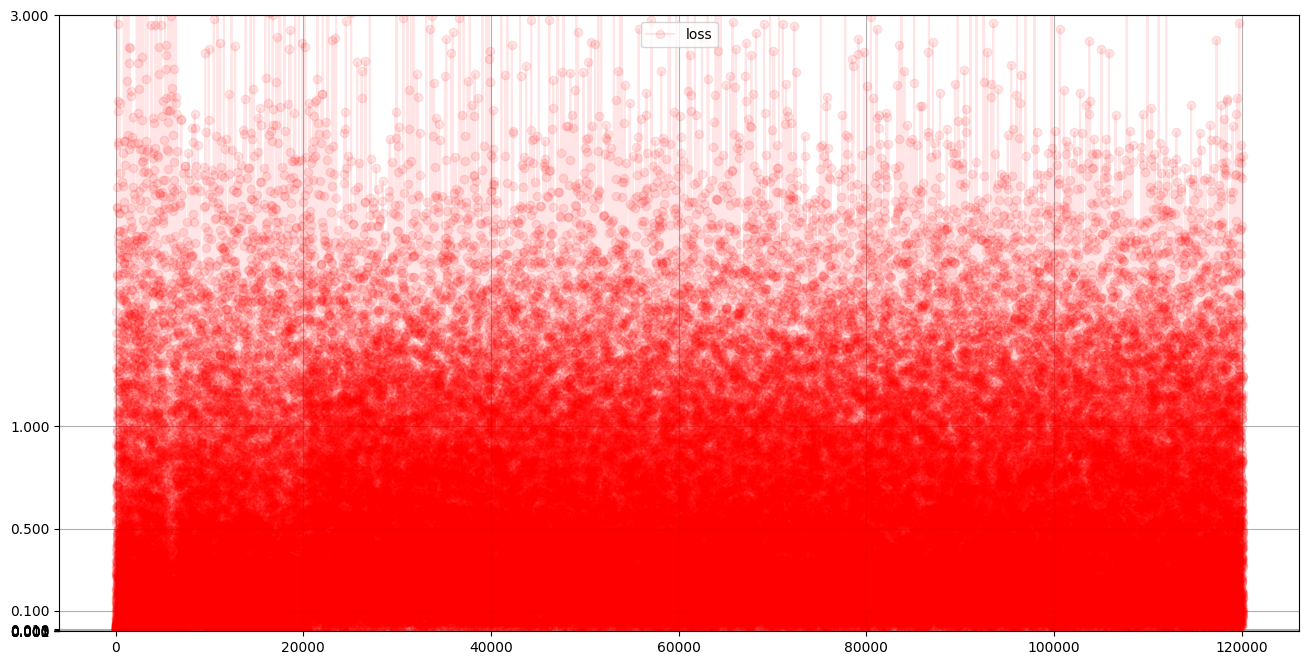

In [36]:
# plot discriminator error
# D.plot_progress()
df = pandas.DataFrame(D.progress, columns=['loss'])
df.plot(ylim=(0,3), figsize=(16,8), alpha=0.1, marker='o', colormap='prism', grid=True, yticks=(0, 0.00025, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.1,0.5, 1.0, 3.0))

<Axes: >

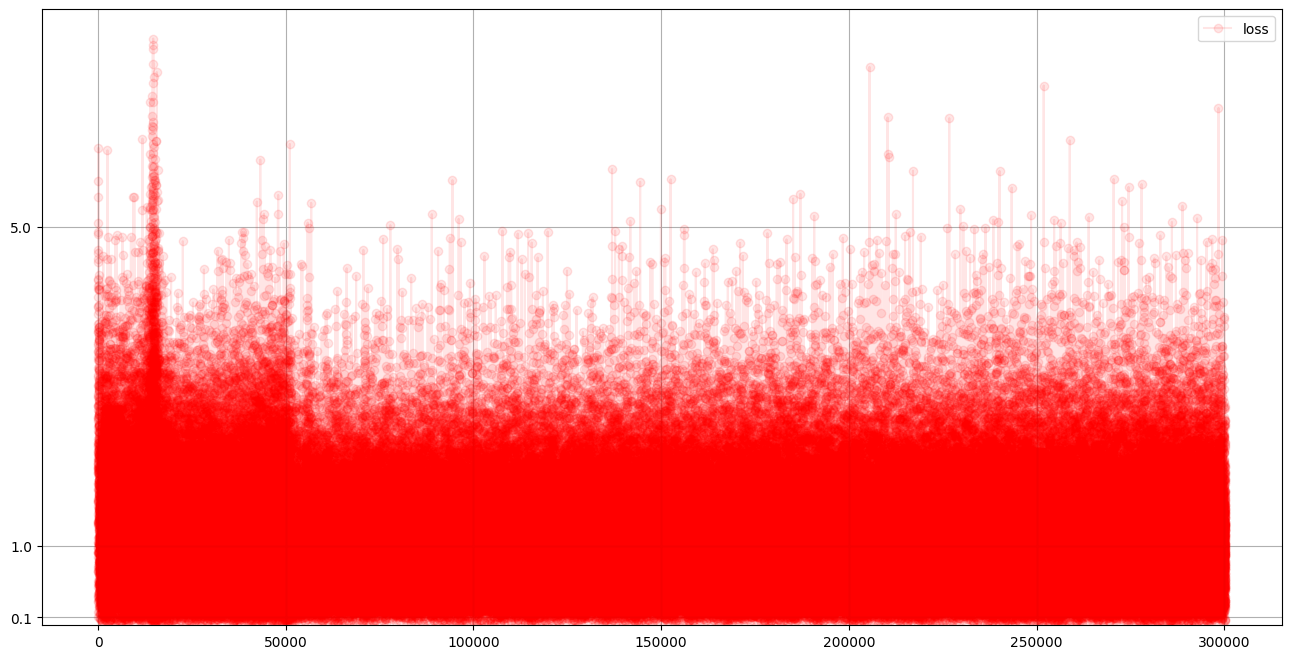

In [37]:
# plot generator error
# G.plot_progress()
df = pandas.DataFrame(G.progress, columns=['loss'])
df.plot(ylim=(0), figsize=(16,8), alpha=0.1, marker='o', colormap='prism', grid=True, yticks=(0.1,1, 5))

## Run Generator

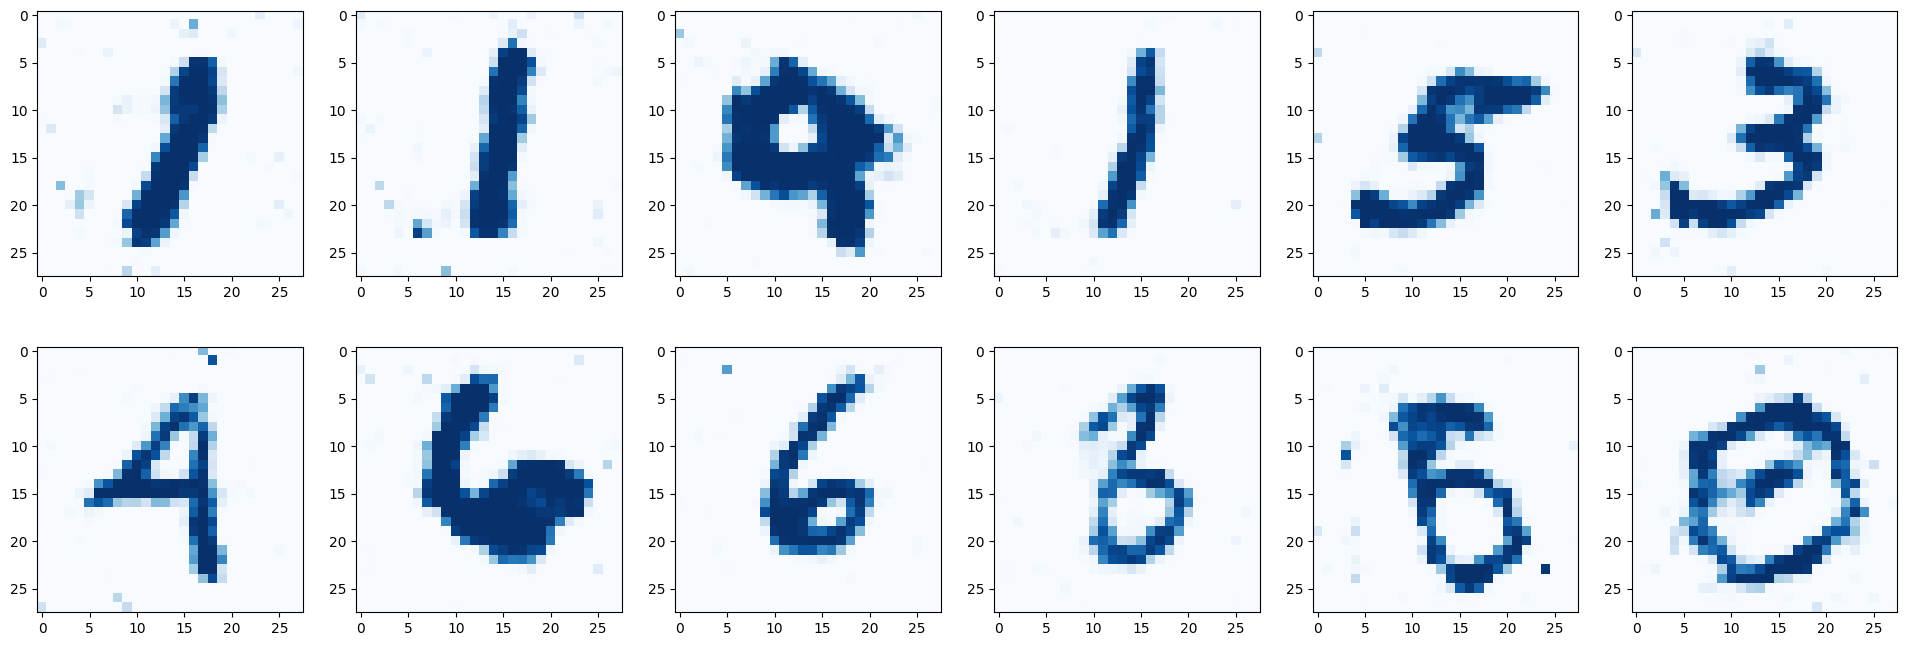

In [38]:
# plot several outputs from the trained generator

# plot a 3 column, 2 row array of generated images
f, axarr = plt.subplots(2,6, figsize=(24,8))
for i in range(2):
    for j in range(6):
        output = G.forward(torch.randn(50).to(device)).to('cpu')
        img = output.detach().numpy().reshape(28,28)
        axarr[i,j].imshow(img, interpolation='none', cmap='Blues')
        pass
    pass

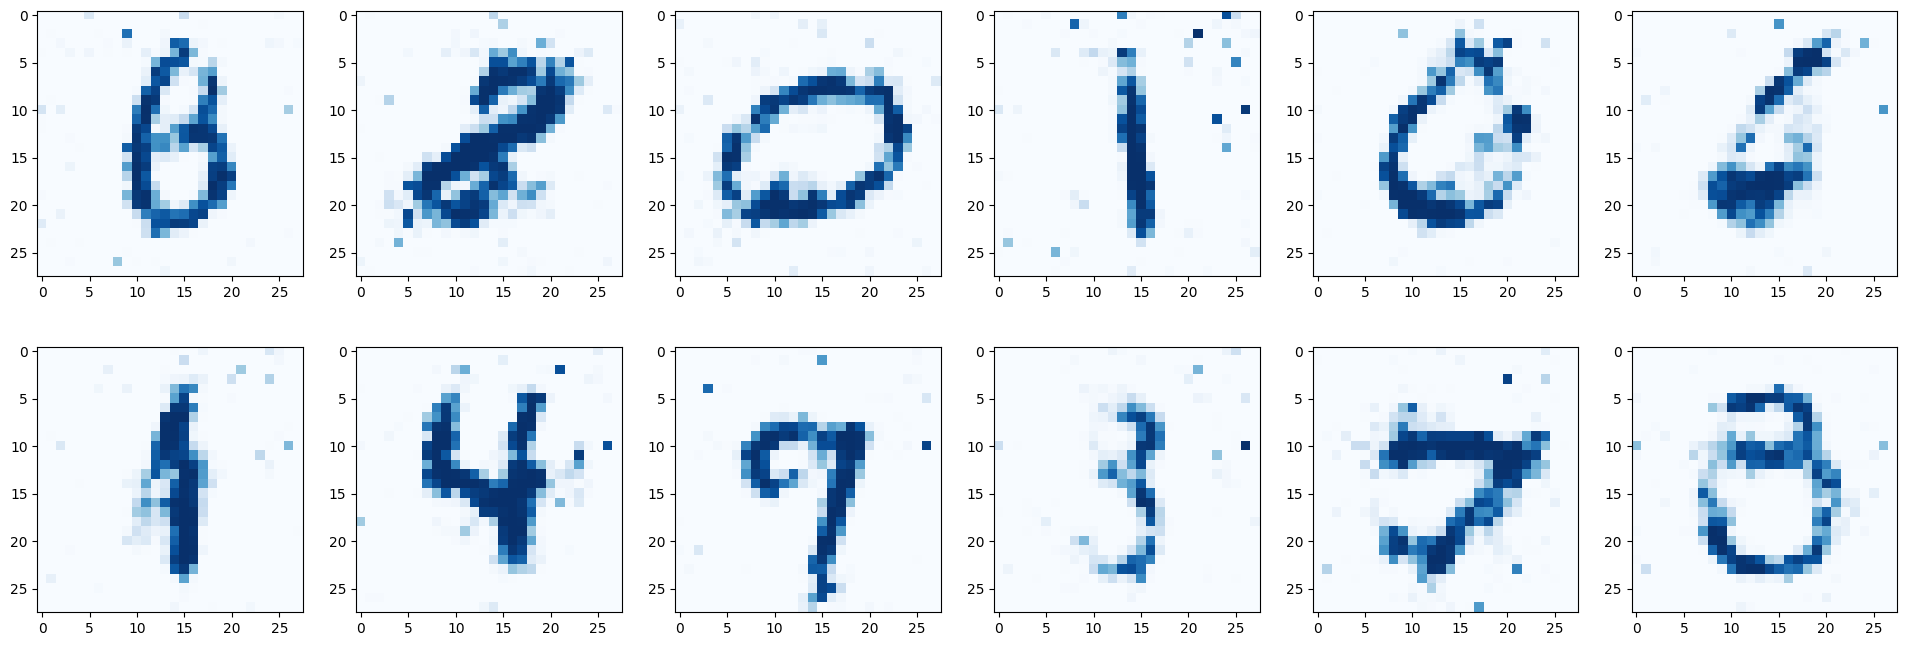

In [33]:
# This is the previous plot, trained with epochs=20 and epoch_size=10000

### 保存此时的generator和Discriminator

In [40]:
torch.save(D.state_dict(), 'mnist_gan_d-5w-50epoch.pth')

In [41]:
torch.save(G.state_dict(), 'mnist_gan_g-5w-50epoch.pth')